In [1]:
import PreProcessedData
import pandas as pd
import sklearn.model_selection as model_selection
from sklearn import svm
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, balanced_accuracy_score, recall_score, f1_score, precision_score
from sklearn.model_selection import PredefinedSplit
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np

In [3]:
data = PreProcessedData.load_data("pv_module_efficiency_dataset.csv")

# Pré-processamento
X_train, X_validation, X_test, _, _, _,  y_train, y_validation, y_test = PreProcessedData.split_data(data, "expected_efficiency", "efficiency_level", 0.3, 42, "Something else")
categorical_cols = ["pv_module_type","hotspot","birddrop","soiling","junction_box"]
numerical_cols=["affected_area","temperature","irradiance","Voc","Isc"]
X_train, X_validation, X_test= PreProcessedData.preprocess_data(X_train, X_validation, X_test, categorical_cols)

X_train_val = pd.concat([X_train, X_validation])
y_train_val = pd.concat([y_train, y_validation])

y_train_val = y_train_val.values.ravel()

split_index = [-1] * len(X_train) + [0] * len(X_validation)
predefined_split = PredefinedSplit(test_fold=split_index)

In [4]:
param_grid = {
    'kernel': ['linear', 'rbf'],  # Kernels to evaluate
    'C': [0.1, 1, 10],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'probability': [True]
}

In [5]:
svc = svm.SVC(class_weight='balanced')
grid = model_selection.GridSearchCV(estimator=svc, param_grid=param_grid, cv=predefined_split, scoring='accuracy')

grid.fit(X_train_val, y_train_val)

cv_results_df = pd.DataFrame(grid.cv_results_)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'linear', 'probability': True}
Best Score: 0.9876666666666667


Test Balanced Accuracy: 0.9896
AUC-ROC: 1.0000
Classification Report: 
               precision    recall  f1-score   support

          bad     0.9867    0.9838    0.9853      2346
extremely_bad     0.9982    0.9934    0.9958      3921
         good     1.0000    0.9862    0.9931      7690
     moderate     0.8834    0.9952    0.9360      1043

     accuracy                         0.9883     15000
    macro avg     0.9671    0.9896    0.9775     15000
 weighted avg     0.9894    0.9883    0.9886     15000



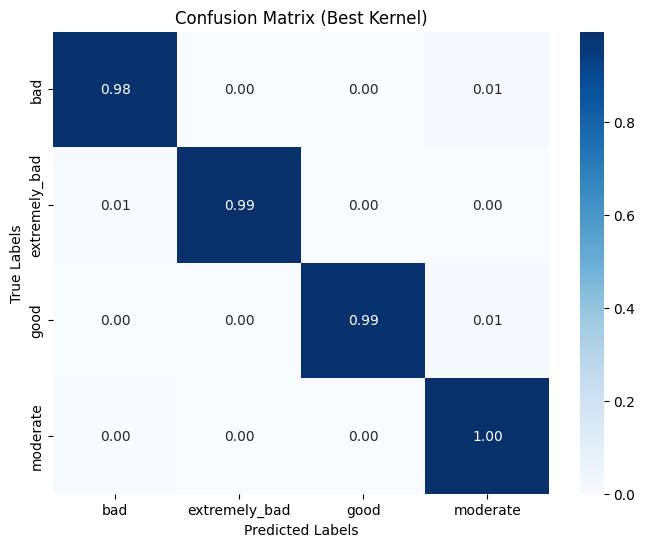

In [9]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

y_test =y_test.values.ravel()
label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)

#print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test_encoded, y_pred_prob, multi_class='ovr', average='weighted'):.4f}")
#print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
#print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
#print(f"Precision Score: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Classification Report: \n{classification_report(y_test, y_pred, digits=4)}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

# Get the unique classes present in the dataset and sort them
unique_classes = sorted(np.unique(np.concatenate([y_test, y_pred])))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Best Kernel)")
plt.show()

In [2]:
data = PreProcessedData.load_data("pv_module_efficiency_dataset.csv")

# Pré-processamento
X_train, X_validation, X_test, _, _, _,  y_train, y_validation, y_test = PreProcessedData.split_data(data, "expected_efficiency", "efficiency_level", 0.3, 42, "Something else")
categorical_cols = ["pv_module_type","hotspot","birddrop","soiling","junction_box"]
numerical_cols=["affected_area","temperature","irradiance","Voc","Isc"]
X_train, X_validation, X_test= PreProcessedData.preprocess_data(X_train, X_validation, X_test, categorical_cols)

In [3]:
X_train = X_train[['affected_area', 'Isc']]
X_validation = X_validation[['affected_area', 'Isc']]
X_test = X_test[['affected_area', 'Isc']]

X_train_val = pd.concat([X_train, X_validation])
y_train_val = pd.concat([y_train, y_validation])
y_train_val = y_train_val.values.ravel()

split_index = [-1] * len(X_train) + [0] * len(X_validation)
predefined_split = PredefinedSplit(test_fold=split_index)

In [4]:
param_grid = {
    'kernel': ['linear', 'rbf'],  # Kernels to evaluate
    'C': [0.1, 1, 10],  # Regularization parameter
    'gamma': ['scale', 'auto'],  # Kernel coefficient
    'probability': [True]
}

In [5]:
svc = svm.SVC(class_weight='balanced')
grid = model_selection.GridSearchCV(estimator=svc, param_grid=param_grid, cv=predefined_split, scoring='accuracy')

grid.fit(X_train_val, y_train_val)

cv_results_df = pd.DataFrame(grid.cv_results_)

print("Best Parameters:", grid.best_params_)
print("Best Score:", grid.best_score_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf', 'probability': True}
Best Score: 0.6517333333333334


c:\Users\lm803\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\preprocessing\_label.py:110: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Test Balanced Accuracy: 0.6981
AUC-ROC: 0.9341
Classification Report: 
               precision    recall  f1-score   support

          bad     0.4626    0.7042    0.5584      2346
extremely_bad     0.8469    0.7353    0.7872      3921
         good     0.9518    0.5938    0.7313      7690
     moderate     0.2454    0.7593    0.3709      1043

     accuracy                         0.6595     15000
    macro avg     0.6267    0.6981    0.6119     15000
 weighted avg     0.7988    0.6595    0.6938     15000



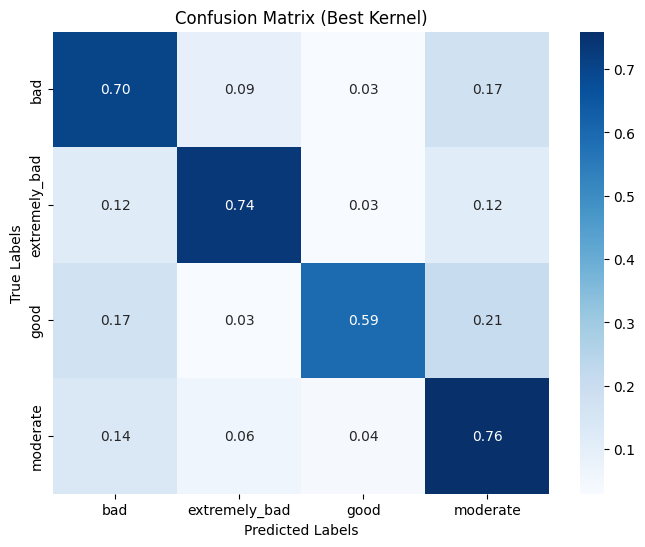

In [7]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)
y_pred_prob = best_model.predict_proba(X_test)

label_encoder = LabelEncoder()
y_test_encoded = label_encoder.fit_transform(y_test)

#print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Balanced Accuracy: {balanced_accuracy_score(y_test, y_pred):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test_encoded, y_pred_prob, multi_class='ovr', average='weighted'):.4f}")
#print(f"Recall: {recall_score(y_test, y_pred, average='weighted'):.4f}")
#print(f"F1-Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
#print(f"Precision Score: {precision_score(y_test, y_pred, average='weighted'):.4f}")
print(f"Classification Report: \n{classification_report(y_test, y_pred, digits=4, zero_division=0.0)}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1, keepdims=True)

y_test = y_test.values.ravel()

# Get the unique classes present in the dataset and sort them
unique_classes = sorted(np.unique(np.concatenate([y_test, y_pred])))

plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=unique_classes, yticklabels=unique_classes)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix (Best Kernel)")
plt.show()
